In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
df = pd.read_csv('../../Data/merged_df.csv')

[대시보드 1] 비즈니스 핵심 지표 요약
총 중복 제거 고객 수: 17,000명
총 누적 매출액: $1,775,451.97
총 거래 건수: 138,953건
평균 객단가(ATV): $12.78
--------------------------------------------------
[전체 오퍼 퍼널 현황]
1단계 - 총 발송 수(Received): 76,277건
2단계 - 총 열람 수(Viewed): 57,725건 (열람률: 75.7%)
3단계 - 총 완료 수(Completed): 33,182건 (최종 완료율: 43.5%)
열람 고객 대비 완료율: 57.5%


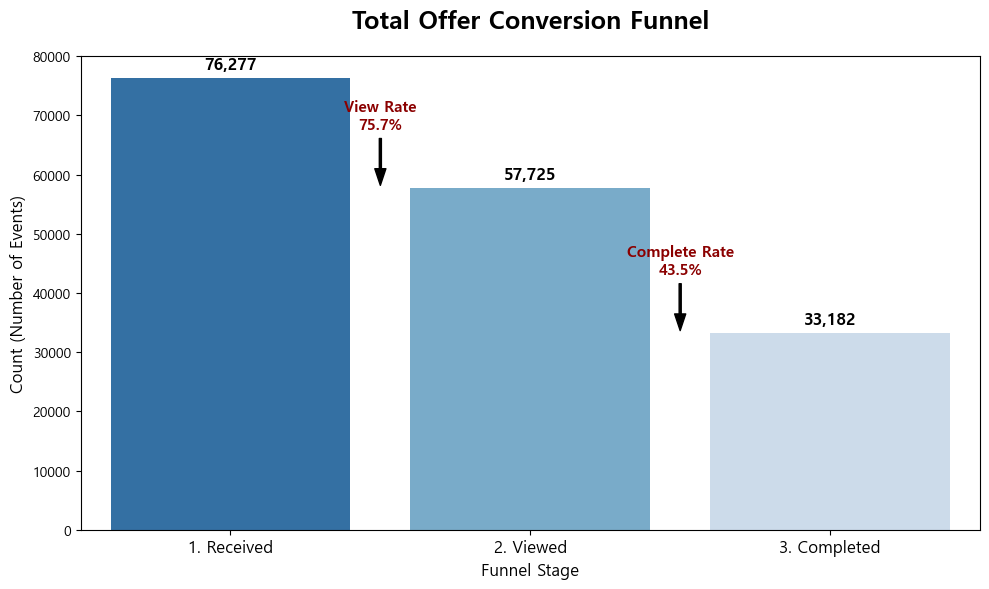

In [5]:
# ==========================================
# 1. 오퍼 퍼널(Funnel) 지표 계산
# ==========================================
# 각 이벤트별 개수 세기 (received, viewed, completed)
funnel_data = df['event'].value_counts()[['received', 'viewed', 'completed']]

total_received = funnel_data['received']
total_viewed = funnel_data['viewed']
total_completed = funnel_data['completed']

# 전환율 계산 (%)
view_rate = (total_viewed / total_received) * 100
complete_rate = (total_completed / total_received) * 100
view_to_complete_rate = (total_completed / total_viewed) * 100

# ==========================================
# 2. 매출 및 결제 핵심 지표 (amount 컬럼 활용)
# ==========================================
# 결제(transaction) 데이터만 필터링
transaction_df = df[df['event'] == 'transaction']

total_revenue = transaction_df['amount'].sum()
total_transactions = transaction_df.shape[0]
atv = total_revenue / total_transactions if total_transactions > 0 else 0  # 객단가(Average Transaction Value)

# ==========================================
# 3. 고객 지표 (전체 고객 수)
# ==========================================
total_customers = df['person'].nunique()

# 결과 출력 브리핑
print("="*50)
print("[대시보드 1] 비즈니스 핵심 지표 요약")
print("="*50)
print(f"총 중복 제거 고객 수: {total_customers:,}명")
print(f"총 누적 매출액: ${total_revenue:,.2f}")
print(f"총 거래 건수: {total_transactions:,}건")
print(f"평균 객단가(ATV): ${atv:,.2f}")
print("-" * 50)
print("[전체 오퍼 퍼널 현황]")
print(f"1단계 - 총 발송 수(Received): {total_received:,}건")
print(f"2단계 - 총 열람 수(Viewed): {total_viewed:,}건 (열람률: {view_rate:.1f}%)")
print(f"3단계 - 총 완료 수(Completed): {total_completed:,}건 (최종 완료율: {complete_rate:.1f}%)")
print(f"열람 고객 대비 완료율: {view_to_complete_rate:.1f}%")
print("="*50)

# ==========================================
#4. 시각화 (Funnel Bar Chart)
# ==========================================
plt.figure(figsize=(10, 6))

# 퍼널 바 차트 그리기
ax = sns.barplot(x=funnel_data.index, y=funnel_data.values, palette="Blues_r")

# 차트 꾸미기
plt.title('Total Offer Conversion Funnel', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Count (Number of Events)', fontsize=12)
plt.xlabel('Funnel Stage', fontsize=12)
plt.xticks([0, 1, 2], ['1. Received', '2. Viewed', '3. Completed'], fontsize=12)

# 막대 위에 숫자(건수 및 전환율) 표시하기
for i, v in enumerate(funnel_data.values):
    ax.text(i, v + (total_received * 0.02), f'{v:,}', ha='center', fontsize=12, fontweight='bold')
    
# 전환율 화살표 & 텍스트 추가 (View Rate)
plt.annotate(f'View Rate\n{view_rate:.1f}%', xy=(0.5, total_viewed), xytext=(0.5, total_viewed + 10000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=11, color='darkred', fontweight='bold')

# 전환율 화살표 & 텍스트 추가 (Complete Rate)
plt.annotate(f'Complete Rate\n{complete_rate:.1f}%', xy=(1.5, total_completed), xytext=(1.5, total_completed + 10000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=11, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

event내에서 transaction(=결제금액)과 completed(=쿠폰정보)가 같은 시간형식(완료시점의 상대시간)을 공유하기 때문에 
person과 time이 동일한 데이터를 하나로 합쳐서 쿠폰정보와 결제금액을 한번에 확인할수 있게함

쿠폰 연계 매출 데이터 결합 완료 
총 매칭된 결제 건수: 33,182건


,person,time,amount,offer_label,offer_id,difficulty,reward
0,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,0,34.56,discount_4,2906b810c7d4411798c6938adc9daaa5,10.0,2.0
1,fe97aa22dd3e48c8b143116a8403dd52,0,18.97,discount_3,fafdcd668e3743c1bb461111dcafc2a4,10.0,2.0
2,629fc02d56414d91bca360decdfa9288,0,33.90,bogo_3,9b98b8c7a33c4b65b9aebfe6a799e6d9,5.0,5.0
3,676506bad68e4161b9bbaffeb039626b,0,18.01,bogo_1,ae264e3637204a6fb9bb56bc8210ddfd,10.0,10.0
4,8f7dd3b2afe14c078eb4f6e6fe4ba97d,0,19.11,bogo_2,4d5c57ea9a6940dd891ad53e9dbe8da0,10.0,10.0



[오퍼별 총 발생 매출 랭킹]


,offer_label,총_연계_매출,결제_건수,건당_평균매출
6,discount_3,96900.1,5265,18.4
5,discount_2,89848.2,5112,17.6
0,bogo_1,87109.9,3635,24.0
4,discount_1,85985.5,3340,25.7
3,bogo_4,83146.9,4262,19.5
7,discount_4,81688.0,3964,20.6
1,bogo_2,78562.1,3301,23.8
2,bogo_3,77066.3,4303,17.9


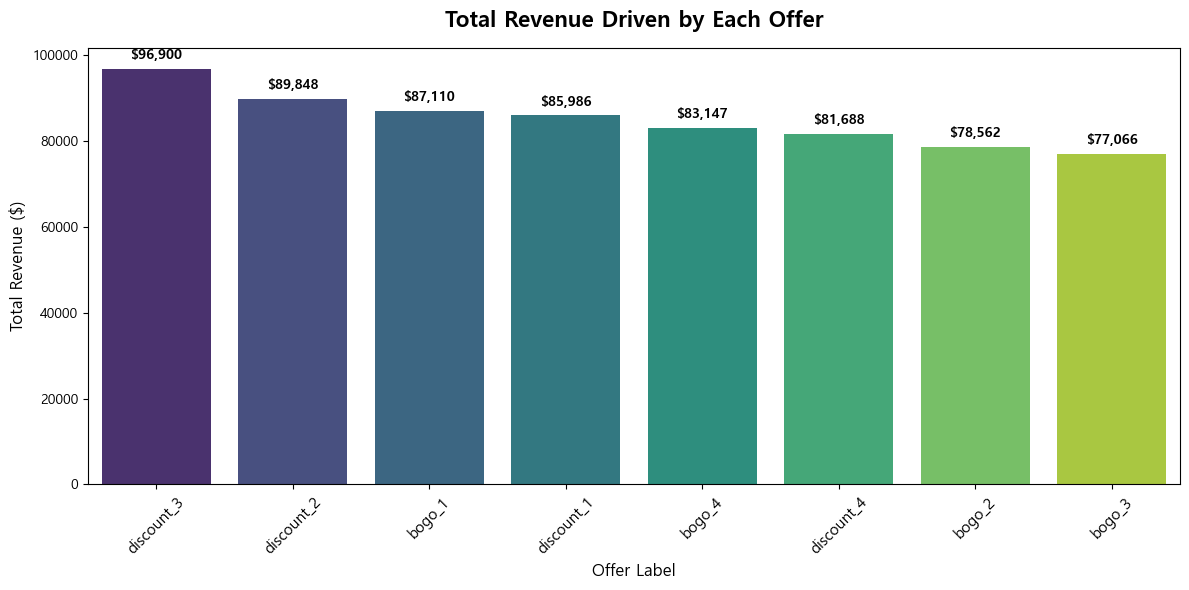

In [9]:
# ==========================================
# 1. 결제 금액과 쿠폰 아이디 연결하기
# ==========================================
# (1) 결제 기록만 떼어내기 (금액 정보만 챙김)
transactions = df[df['event'] == 'transaction'][['person', 'time', 'amount']]

# (2) 쿠폰 완료 기록만 떼어내기 (쿠폰 정보만 챙김)
completions = df[df['event'] == 'completed'][['person', 'time', 'offer_label', 'offer_id', 'difficulty', 'reward']]

# (3) 두 데이터를 '사람'과 '시간' 기준으로 하나로 합치기
# 쿠폰을 써서 발생한 진짜 매출만 남기기
matched_sales = pd.merge(transactions, completions, on=['person', 'time'], how='inner')

print("="*60)
print("쿠폰 연계 매출 데이터 결합 완료 ")
print(f"총 매칭된 결제 건수: {len(matched_sales):,}건")
print("="*60)
display(matched_sales.head())

# ==========================================
# 2. 어떤 쿠폰이 돈을 가장 많이 벌었나
# ==========================================
# 쿠폰(offer_label)별로 발생시킨 총 매출(sum), 결제 건수(count), 평균 결제 금액(mean) 계산
offer_revenue = matched_sales.groupby('offer_label').agg(
    총_연계_매출=('amount', 'sum'),
    결제_건수=('amount', 'count'),
    건당_평균매출=('amount', 'mean') # 쿠폰별 객단가
).reset_index()

# 총 매출 기준으로 내림차순 정렬
offer_revenue = offer_revenue.sort_values(by='총_연계_매출', ascending=False).round(1)

print("\n" + "="*60)
print("[오퍼별 총 발생 매출 랭킹]")
display(offer_revenue)

# ==========================================
# 3. 시각화: 오퍼별 총 매출액 (Bar Chart)
# ==========================================
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=offer_revenue, x='offer_label', y='총_연계_매출', palette='viridis')

plt.title('Total Revenue Driven by Each Offer', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xlabel('Offer Label', fontsize=12)

# 막대 위에 금액 표시
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

bogo_1 : 달성 조건(difficulty) 10달러 ➔ 혜택(reward) 10달러 ➔ 유효기간(duration) 7일 ➔ [이메일, 모바일, 소셜]로 발송됨

bogo_2 : 달성 조건(difficulty) 10달러 ➔ 혜택(reward) 10달러 ➔ 유효기간(duration) 5일 ➔ [웹, 이메일, 모바일, 소셜]로 발송됨

bogo_3 : 달성 조건(difficulty) 5달러 ➔ 혜택(reward) 5달러 ➔ 유효기간(duration) 7일 ➔ [웹, 이메일, 모바일]로 발송됨

bogo_4 : 달성 조건(difficulty) 5달러 ➔ 혜택(reward) 5달러 ➔ 유효기간(duration) 5일 ➔ [웹, 이메일, 모바일, 소셜]로 발송됨

discount_1 : 달성 조건(difficulty) 20달러 ➔ 혜택(reward) 5달러 ➔ 유효기간(duration) 10일 ➔ [웹, 이메일]로 발송됨

discount_2 : 달성 조건(difficulty) 7달러 ➔ 혜택(reward) 3달러 ➔ 유효기간(duration) 7일 ➔ [웹, 이메일, 모바일, 소셜]로 발송됨

discount_3 : 달성 조건(difficulty) 10달러 ➔ 혜택(reward) 2달러 ➔ 유효기간(duration) 10일 ➔ [웹, 이메일, 모바일, 소셜]로 발송됨

discount_4 : 달성 조건(difficulty) 10달러 ➔ 혜택(reward) 2달러 ➔ 유효기간(duration) 7일 ➔ [웹, 이메일, 모바일]로 발송됨

In [ ]:
# 1. 'received'(발송) 기록만 떼어내기
received_df = df[df['event'] == 'received']

# 2. 오퍼별로 총 발송 수 세기
offer_sent = received_df.groupby('offer_label').size().reset_index(name='총_발송_수')

# 3. 오퍼별 채널 정보(1 or 0) 매핑하기 (중복 제거해서 스펙만 가져옴)
channel_info = df[['offer_label', 'web', 'email', 'mobile', 'social']].drop_duplicates()

# 4. 발송 수와 채널 정보 합치기
offer_channel_summary = pd.merge(offer_sent, channel_info, on='offer_label')

# 5. Informational (정보성) 오퍼 2개는 분석에서 제외
offer_channel_summary = offer_channel_summary[~offer_channel_summary['offer_label'].str.contains('informational')]

# 6. 실제 채널별 발송 건수 계산 (총_발송_수 * 1 or 0)
offer_channel_summary['Web_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['web']
offer_channel_summary['Email_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['email']
offer_channel_summary['Mobile_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['mobile']
offer_channel_summary['Social_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['social']

# 보기 편하게 필요한 컬럼만 정리해서 출력
final_display = offer_channel_summary[['offer_label', '총_발송_수', 'Web_발송건수', 'Email_발송건수', 'Mobile_발송건수', 'Social_발송건수']]

print("="*80)
print("[오퍼 8종] 오퍼별 & 채널별 실제 발송 건수 현황")
print("="*80)
display(final_display.sort_values('총_발송_수', ascending=False))

[오퍼 8종] 오퍼별 & 채널별 실제 발송 건수 현황


,offer_label,총_발송_수,Web_발송건수,Email_발송건수,Mobile_발송건수,Social_발송건수
2,bogo_3,7677,7677.0,7677.0,7677.0,0.0
4,discount_1,7668,7668.0,7668.0,0.0,0.0
0,bogo_1,7658,0.0,7658.0,7658.0,7658.0
5,discount_2,7646,7646.0,7646.0,7646.0,7646.0
7,discount_4,7632,7632.0,7632.0,7632.0,0.0
6,discount_3,7597,7597.0,7597.0,7597.0,7597.0
1,bogo_2,7593,7593.0,7593.0,7593.0,7593.0
3,bogo_4,7571,7571.0,7571.0,7571.0,7571.0


In [11]:
# 1. 'received'(발송) 기록만 떼어내기
received_df = df[df['event'] == 'received']

# 2. 오퍼별로 총 발송 수 세기
offer_sent = received_df.groupby('offer_label').size().reset_index(name='총_발송_수')

# 3. 오퍼별 채널 정보(1 or 0) 매핑하기 (중복 제거해서 스펙만 가져옴)
channel_info = df[['offer_label', 'web', 'email', 'mobile', 'social']].drop_duplicates()

# 4. 발송 수와 채널 정보 합치기
offer_channel_summary = pd.merge(offer_sent, channel_info, on='offer_label')

# 정보성 오퍼 포함

# 5. 실제 채널별 발송 건수 계산 (총_발송_수 * 1 or 0)
offer_channel_summary['Web_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['web']
offer_channel_summary['Email_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['email']
offer_channel_summary['Mobile_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['mobile']
offer_channel_summary['Social_발송건수'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['social']

# 6. 보기 편하게 필요한 컬럼만 정리해서 출력
final_display = offer_channel_summary[['offer_label', '총_발송_수', 'Web_발송건수', 'Email_발송건수', 'Mobile_발송건수', 'Social_발송건수']]

print("="*80)
print("[전체 오퍼 10종] 오퍼별 & 채널별 실제 발송 건수 현황 (정보성 포함)")
print("="*80)
# int(정수) 형태로 깔끔하게 보기 위해 변환 후 출력
display(final_display.astype({'Web_발송건수':'int', 'Email_발송건수':'int', 'Mobile_발송건수':'int', 'Social_발송건수':'int'}).sort_values('총_발송_수', ascending=False))

[전체 오퍼 10종] 오퍼별 & 채널별 실제 발송 건수 현황 (정보성 포함)


,offer_label,총_발송_수,Web_발송건수,Email_발송건수,Mobile_발송건수,Social_발송건수
2,bogo_3,7677,7677,7677,7677,0
4,discount_1,7668,7668,7668,0,0
0,bogo_1,7658,0,7658,7658,7658
5,discount_2,7646,7646,7646,7646,7646
7,discount_4,7632,7632,7632,7632,0
9,informational_2,7618,0,7618,7618,7618
8,informational_1,7617,7617,7617,7617,0
6,discount_3,7597,7597,7597,7597,7597
1,bogo_2,7593,7593,7593,7593,7593
3,bogo_4,7571,7571,7571,7571,7571


웹: 홈페이지 드갔을때 팝업, 마이페이지 알림
이메일: 이메일
모바일: sms보다는 스벅 앱 알림일 확률 높음
소셜: sns

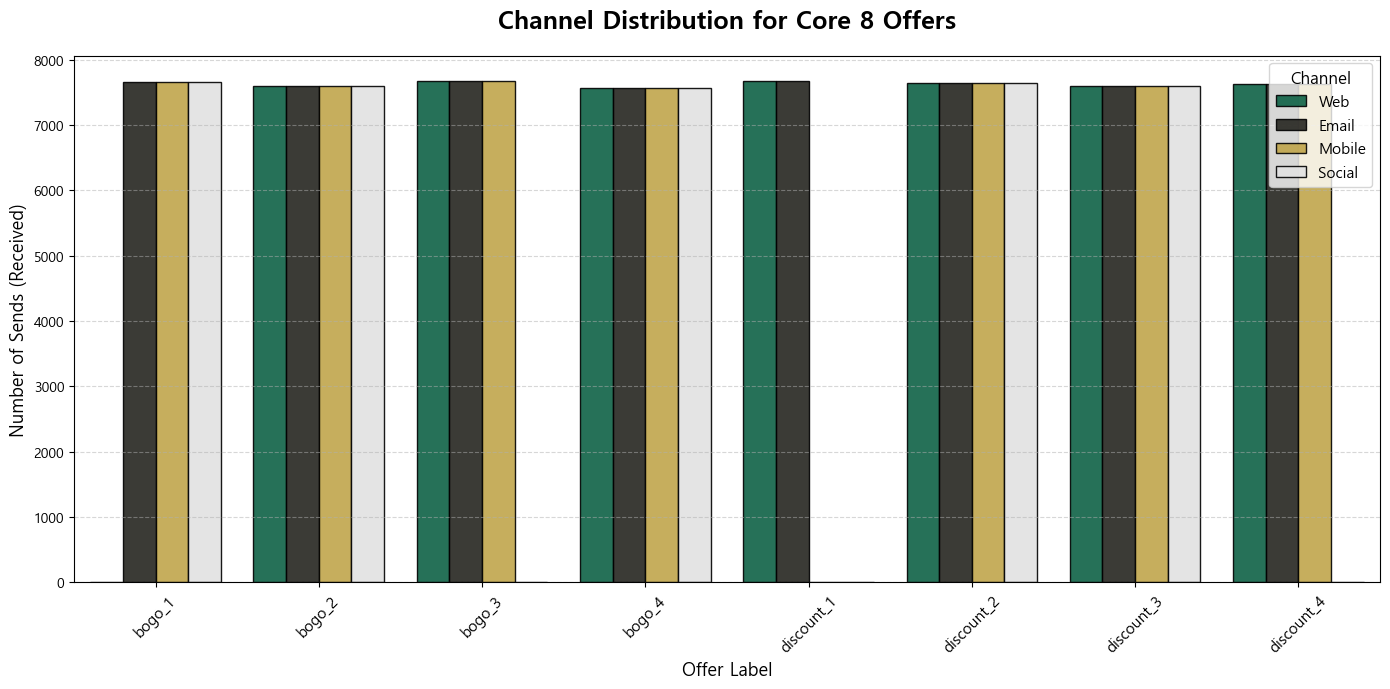

In [12]:
# 1. 'received'(발송) 기록만 떼어내기
received_df = df[df['event'] == 'received']

# 2. 오퍼별로 총 발송 수 세기 및 채널 정보 병합
offer_sent = received_df.groupby('offer_label').size().reset_index(name='총_발송_수')
channel_info = df[['offer_label', 'web', 'email', 'mobile', 'social']].drop_duplicates()
offer_channel_summary = pd.merge(offer_sent, channel_info, on='offer_label')

# 3. Informational (정보성) 오퍼 2개 제외
offer_channel_summary = offer_channel_summary[~offer_channel_summary['offer_label'].str.contains('informational')]

# 4. 실제 채널별 발송 건수 계산
offer_channel_summary['Web'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['web']
offer_channel_summary['Email'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['email']
offer_channel_summary['Mobile'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['mobile']
offer_channel_summary['Social'] = offer_channel_summary['총_발송_수'] * offer_channel_summary['social']

# 5. 시각화를 위해 데이터 형태 변환 (Melt)
plot_df = offer_channel_summary[['offer_label', 'Web', 'Email', 'Mobile', 'Social']]
plot_df = plot_df.melt(id_vars='offer_label', var_name='Channel', value_name='Send_Count')

# ==========================================
# 6. 시각화 (Grouped Bar Chart)
# ==========================================
plt.figure(figsize=(14, 7))

# 막대그래프 그리기
ax = sns.barplot(data=plot_df, x='offer_label', y='Send_Count', hue='Channel', 
                 palette={'Web': '#00704A', 'Email': '#27251F', 'Mobile': '#D4AF37', 'Social': '#E2E2E2'},
                 edgecolor='black', alpha=0.9)

plt.title('Channel Distribution for Core 8 Offers', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Offer Label', fontsize=13)
plt.ylabel('Number of Sends (Received)', fontsize=13)
plt.xticks(rotation=45, fontsize=11)
plt.legend(title='Channel', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
# 정보성(Informational) 오퍼는 데이터에서 제외하고 시작
# (offer_label이 결측치가 아닌 것들 중, 'informational'이 안 들어간 것만 남김)
df_core = df[df['offer_label'].notna()]
df_core = df_core[~df_core['offer_label'].str.contains('informational')]

# ==========================================
# 1. 퍼널 지표 (발송, 열람, 완료, 완료율) 계산
# ==========================================
# 오퍼별/이벤트별 건수 집계
funnel = df_core.pivot_table(index='offer_label', columns='event', values='person', aggfunc='count', fill_value=0)
funnel = funnel[['received', 'viewed', 'completed']] # 순서대로 정렬

# 전체 완료율 계산 (%)
funnel['전체 완료율(%)'] = (funnel['completed'] / funnel['received'] * 100).round(1)

# ==========================================
# 2. 매출 지표 (탐정 놀이: 결제-완료 매칭) 계산
# ==========================================
# 결제 기록과 완료 기록 떼어내기 (원본 df에서 가져옴)
transactions = df[df['event'] == 'transaction'][['person', 'time', 'amount']]
completions = df_core[df_core['event'] == 'completed'][['person', 'time', 'offer_label']]

# '사람'과 '시간'으로 연결하여 연계 매출 데이터 생성
matched_sales = pd.merge(transactions, completions, on=['person', 'time'], how='inner')

# 오퍼별 총 매출액과 결제 건수 집계
revenue_df = matched_sales.groupby('offer_label').agg(
    총_오퍼_연계_매출=('amount', 'sum'),
    결제건수=('amount', 'count')
)

# ==========================================
# 3. 퍼널과 매출 데이터 하나로 합치고 추가 지표 계산
# ==========================================
final_kpi_df = funnel.join(revenue_df)

# 파생 지표 계산
final_kpi_df['발송 1건당 평균 매출($)'] = (final_kpi_df['총_오퍼_연계_매출'] / final_kpi_df['received']).round(2)
final_kpi_df['완료 1건당 평균 매출($)'] = (final_kpi_df['총_오퍼_연계_매출'] / final_kpi_df['completed']).round(2)
final_kpi_df['평균 객단가($)'] = (final_kpi_df['총_오퍼_연계_매출'] / final_kpi_df['결제건수']).round(2)

# ==========================================
# 4. 대시보드용으로 깔끔하게 컬럼명 정리 및 출력
# ==========================================
final_kpi_df = final_kpi_df.rename(columns={
    'received': '총 발송 수',
    'viewed': '총 열람 수',
    'completed': '총 완료 수'
})

# 선샌니가 요청하신 순서대로 컬럼 재배치!
final_kpi_df = final_kpi_df[['총 발송 수', '총 열람 수', '총 완료 수', '전체 완료율(%)', 
                             '총_오퍼_연계_매출', '발송 1건당 평균 매출($)', '완료 1건당 평균 매출($)', '평균 객단가($)']]

# 총 연계 매출을 기준으로 1등부터 줄 세우기!
final_kpi_df = final_kpi_df.sort_values(by='총_오퍼_연계_매출', ascending=False)

print("="*100)
print("[대시보드 2] 오퍼 8종 총괄 성과")
print("="*100)
# 금액에 콤마 찍어서 보기 좋게 포맷팅
format_dict = {'총_오퍼_연계_매출': '${0:,.2f}', '발송 1건당 평균 매출($)': '${0:,.2f}', 
               '완료 1건당 평균 매출($)': '${0:,.2f}', '평균 객단가($)': '${0:,.2f}',
               '총 발송 수': '{:,}', '총 열람 수': '{:,}', '총 완료 수': '{:,}'}
display(final_kpi_df.style.format(format_dict))

[대시보드 2] 오퍼 8종 총괄 성과


,총 발송 수,총 열람 수,총 완료 수,전체 완료율(%),총_오퍼_연계_매출,발송 1건당 평균 매출($),완료 1건당 평균 매출($),평균 객단가($)
offer_label,,,,,,,,
discount_3,"7,597","7,327","5,265",69.300000,"$96,900.08",$12.76,$18.40,$18.40
discount_2,"7,646","7,337","5,112",66.900000,"$89,848.17",$11.75,$17.58,$17.58
bogo_1,"7,658","6,716","3,635",47.500000,"$87,109.94",$11.38,$23.96,$23.96
discount_1,"7,668","2,663","3,340",43.600000,"$85,985.53",$11.21,$25.74,$25.74
bogo_4,"7,571","7,264","4,262",56.300000,"$83,146.93",$10.98,$19.51,$19.51
discount_4,"7,632","4,118","3,964",51.900000,"$81,687.95",$10.70,$20.61,$20.61
bogo_2,"7,593","7,298","3,301",43.500000,"$78,562.14",$10.35,$23.80,$23.80
bogo_3,"7,677","4,171","4,303",56.100000,"$77,066.31",$10.04,$17.91,$17.91


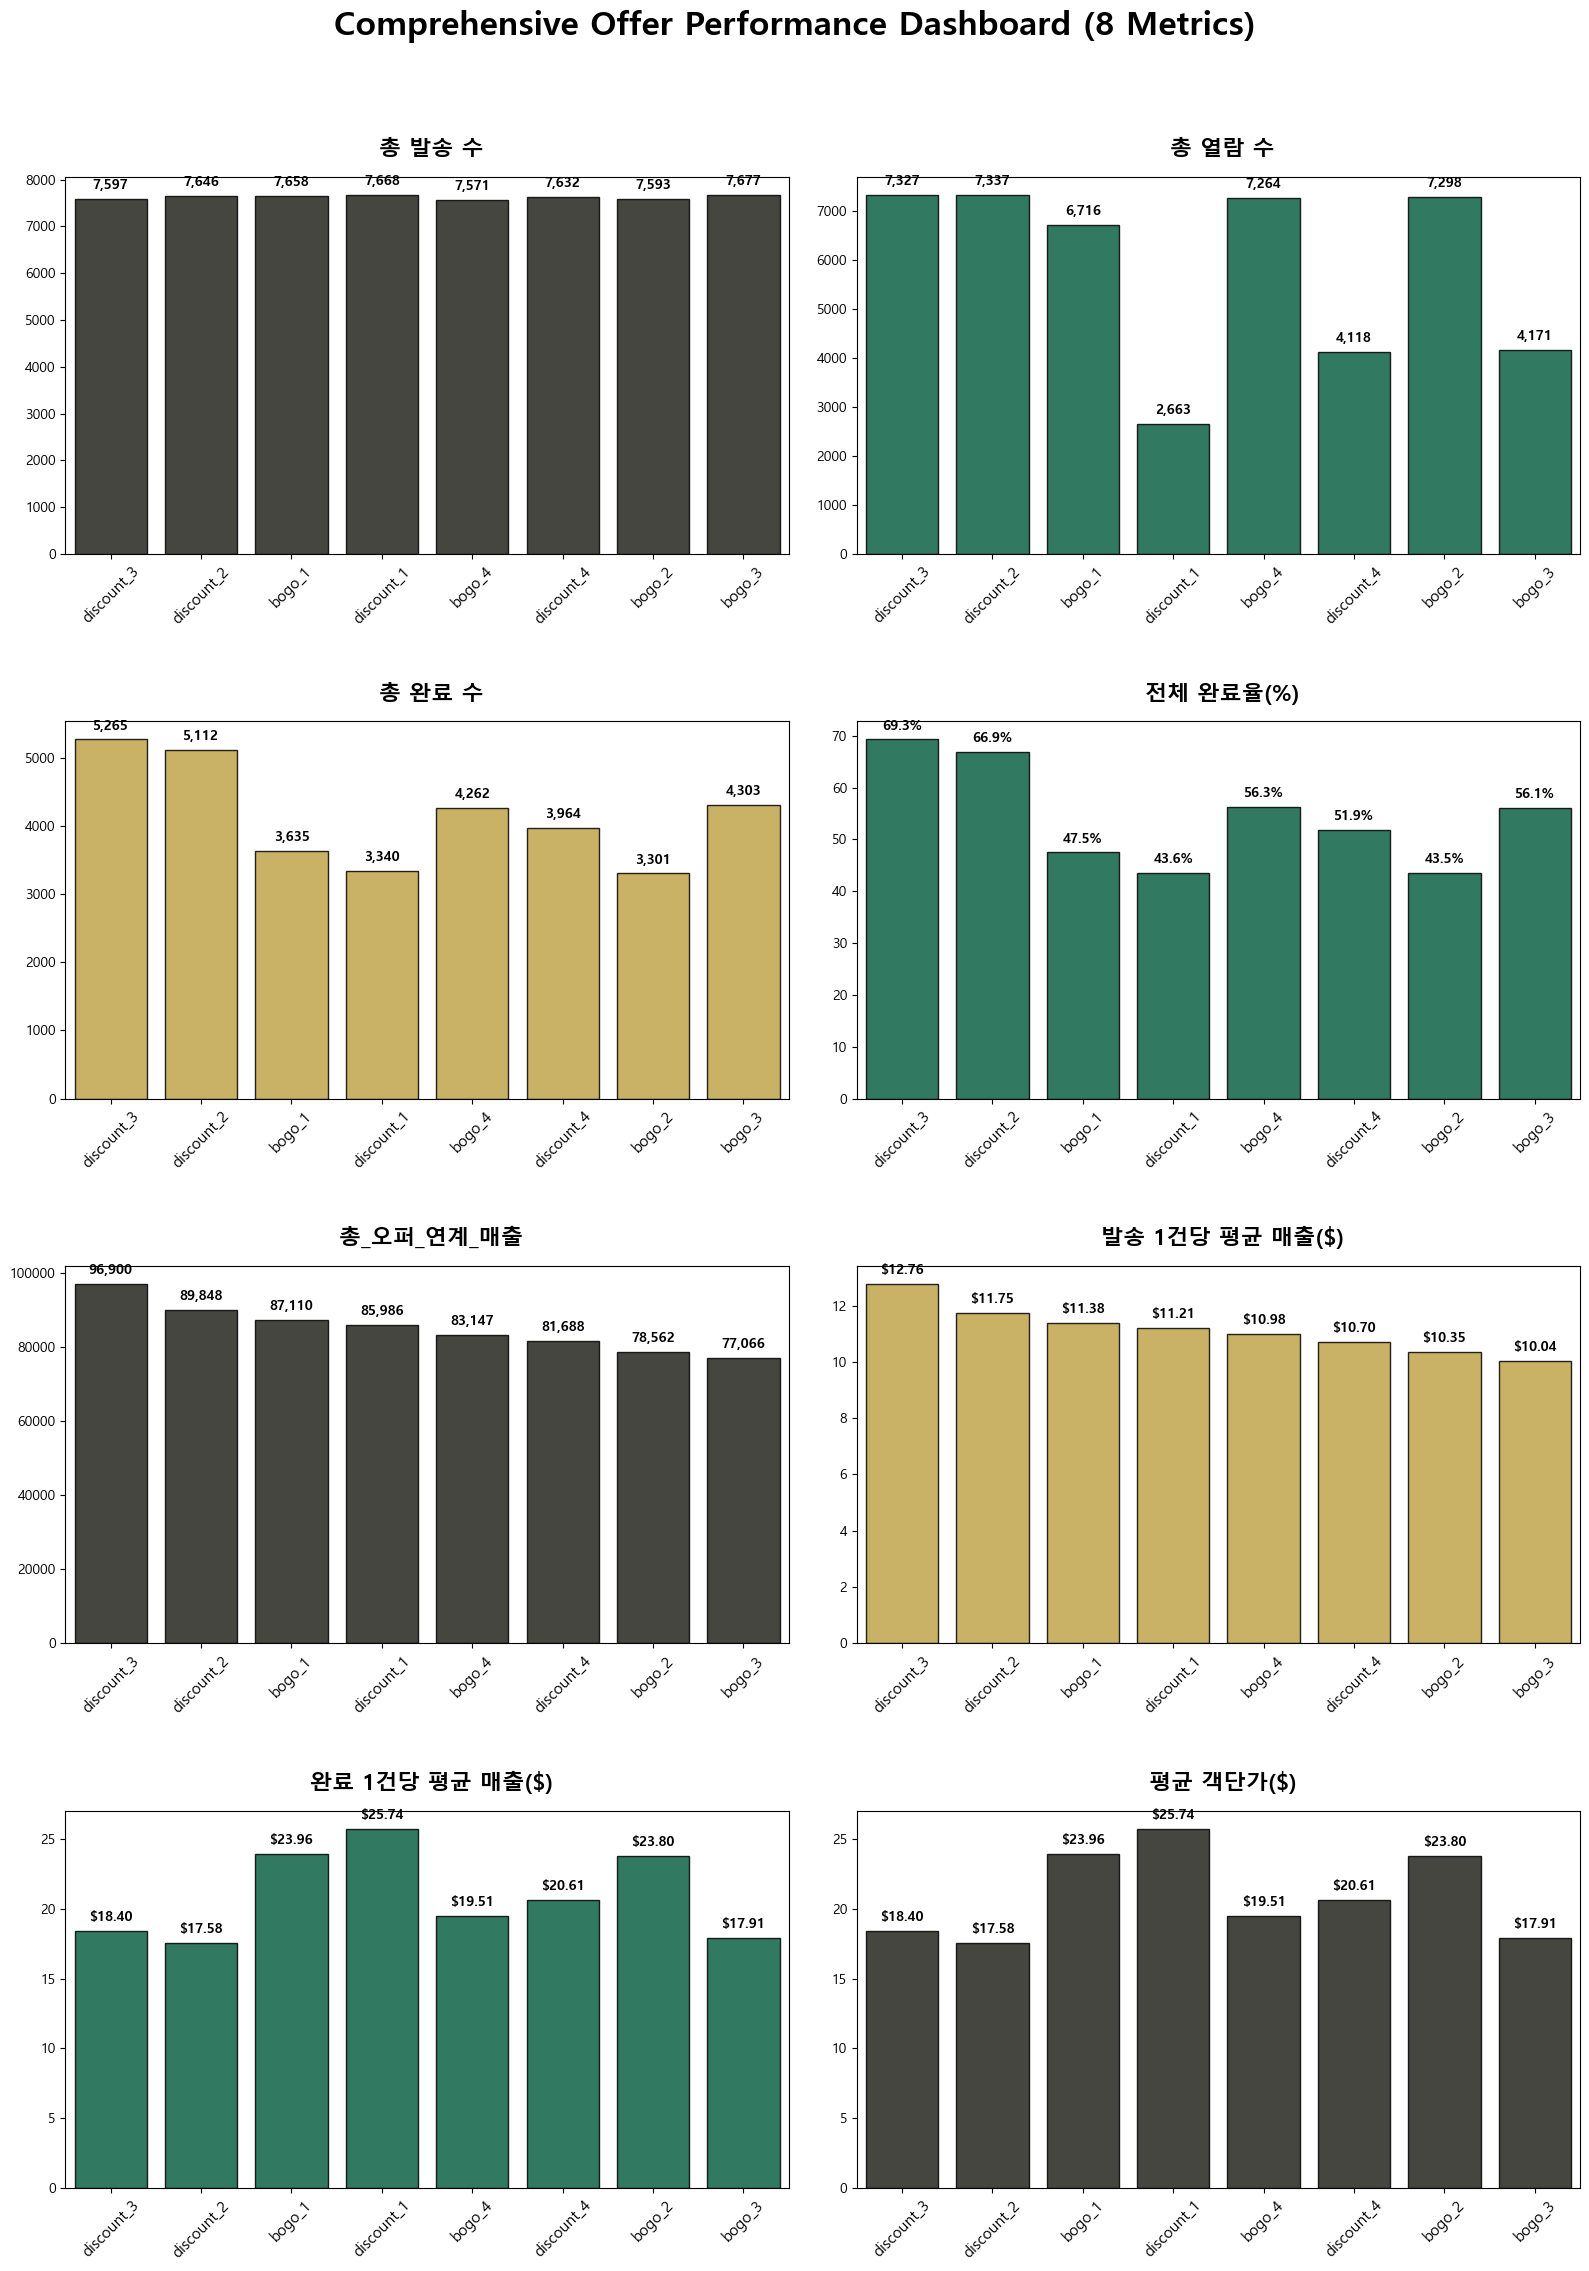

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = final_kpi_df.reset_index()

# 8개의 지표(컬럼명) 리스트
metrics = [
    '총 발송 수', '총 열람 수', '총 완료 수', '전체 완료율(%)', 
    '총_오퍼_연계_매출', '발송 1건당 평균 매출($)', '완료 1건당 평균 매출($)', '평균 객단가($)'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

colors = ['#27251F', '#00704A', '#D4AF37', '#00704A', '#27251F', '#D4AF37', '#00704A', '#27251F']

# 8개 지표를 하나씩 꺼내서 미니 바 차트 그리기
for i, metric in enumerate(metrics):
    sns.barplot(data=plot_df, x='offer_label', y=metric, ax=axes[i], color=colors[i], alpha=0.85, edgecolor='black')
    
    # 각 미니 차트의 제목 설정 
    axes[i].set_title(f" {metric}", fontsize=16, fontweight='bold', pad=15)
    axes[i].set_xlabel('') 
    axes[i].set_ylabel('')
    
    # X축 글자(오퍼 이름) 45도 기울이고, 겹치지 않게 간격 조정
    axes[i].tick_params(axis='x', rotation=45, labelsize=11)
    
    # 막대 위에 숫자 달아주기 (지표마다 포맷 다르게 적용)
    for p in axes[i].patches:
        val = p.get_height()
        if '($)' in metric and '총' in metric:
            text = f'${val:,.0f}'
        elif '($)' in metric:
            text = f'${val:.2f}' 
        elif '%' in metric:
            text = f'{val:.1f}%' 
        else:
            text = f'{val:,.0f}' 
            
        axes[i].annotate(text, (p.get_x() + p.get_width() / 2., val),
                         ha='center', va='bottom', fontsize=10, fontweight='bold', 
                         xytext=(0, 5), textcoords='offset points')

# 전체 대시보드 제목 달기
plt.suptitle('Comprehensive Offer Performance Dashboard (8 Metrics)', fontsize=24, fontweight='bold', y=1.03)

plt.tight_layout(h_pad=4.0, w_pad=2.0)
plt.show()

In [22]:
# ==========================================
#  1. 매출 매칭-위에 했던거
# ==========================================
# 정보성(Informational) 오퍼는 매출/완료 기록이 없으므로 분석에서 제외
df_core = df[df['offer_label'].notna()]
df_core = df_core[~df_core['offer_label'].str.contains('informational')]

# 결제(transaction)와 완료(completed)를 시간과 사람 기준으로 합치기
transactions = df[df['event'] == 'transaction'][['person', 'time', 'amount']]
completions = df_core[df_core['event'] == 'completed'][['person', 'time', 'offer_label']]
matched_sales = pd.merge(transactions, completions, on=['person', 'time'], how='inner')

# 채널 정보(web, email, mobile, social)를 오퍼별로 떼어와서 매출 데이터에 붙이기
channel_info = df_core[['offer_label', 'web', 'email', 'mobile', 'social']].drop_duplicates()
matched_sales = pd.merge(matched_sales, channel_info, on='offer_label', how='left')

# ==========================================
# 2. 채널별 8대 지표 계산 로직
# ==========================================
channels = ['web', 'email', 'mobile', 'social']
channel_kpi_list = []

for ch in channels:
    # A. 해당 채널이 포함된 오퍼의 행동 데이터만 추출
    ch_received_data = df_core[(df_core[ch] == 1) & (df_core['event'] == 'received')]
    ch_viewed_data = df_core[(df_core[ch] == 1) & (df_core['event'] == 'viewed')]
    ch_completed_data = df_core[(df_core[ch] == 1) & (df_core['event'] == 'completed')]
    
    # B. 해당 채널이 포함된 오퍼의 연계 매출 데이터만 추출
    ch_sales_data = matched_sales[matched_sales[ch] == 1]
    
    # C. 기초 숫자 계산
    total_received = len(ch_received_data)
    total_viewed = len(ch_viewed_data)
    total_completed = len(ch_completed_data)
    total_revenue = ch_sales_data['amount'].sum()
    total_tx_count = len(ch_sales_data)
    
    # D. 8대 KPI 지표 계산 (분모가 0인 경우 방어 로직 포함)
    view_rate = (total_viewed / total_received * 100) if total_received > 0 else 0
    comp_rate = (total_completed / total_received * 100) if total_received > 0 else 0
    avg_rev_per_comp = (total_revenue / total_completed) if total_completed > 0 else 0
    atv = (total_revenue / total_tx_count) if total_tx_count > 0 else 0
    rev_per_send = (total_revenue / total_received) if total_received > 0 else 0
    
    # E. 리스트에 저장
    channel_kpi_list.append({
        '채널(Channel)': ch.upper(),
        '총 발송 수': total_received,
        '열람률(%)': round(view_rate, 1),
        '완료율(%)': round(comp_rate, 1),
        '총 매출($)': total_revenue,
        '평균 매출(완료건당 $)': round(avg_rev_per_comp, 2),
        '객단가($)': round(atv, 2),
        '거래 횟수': total_tx_count,
        '발송 1건당 매출($)': round(rev_per_send, 2)
    })

# ==========================================
# 3. 결과 테이블 정리 및 출력
# ==========================================
channel_kpi_df = pd.DataFrame(channel_kpi_list)

#'총 매출' 높은 순으로 정렬
channel_kpi_df = channel_kpi_df.sort_values(by='총 매출($)', ascending=False).reset_index(drop=True)

print("="*110)
print("[대시보드 2] 채널별 KPI 요약 ")
print("="*110)

# 숫자 가독성을 위해 콤마와 달러 표시 포맷팅
format_dict = {
    '총 발송 수': '{:,}', '거래 횟수': '{:,}',
    '총 매출($)': '${0:,.2f}', '평균 매출(완료건당 $)': '${0:,.2f}', 
    '객단가($)': '${0:,.2f}', '발송 1건당 매출($)': '${0:,.2f}'
}
display(channel_kpi_df.style.format(format_dict))

[대시보드 2] 채널별 KPI 요약 


,채널(Channel),총 발송 수,열람률(%),완료율(%),총 매출($),평균 매출(완료건당 $),객단가($),거래 횟수,발송 1건당 매출($)
0,EMAIL,"61,042",76.800000,54.400000,"$680,307.05",$20.50,$20.50,"33,182",$11.14
1,MOBILE,"53,374",82.900000,55.900000,"$594,321.52",$19.92,$19.92,"29,842",$11.14
2,WEB,"53,384",75.300000,55.300000,"$593,197.11",$20.08,$20.08,"29,547",$11.11
3,SOCIAL,"38,065",94.400000,56.700000,"$435,567.26",$20.19,$20.19,"21,575",$11.44


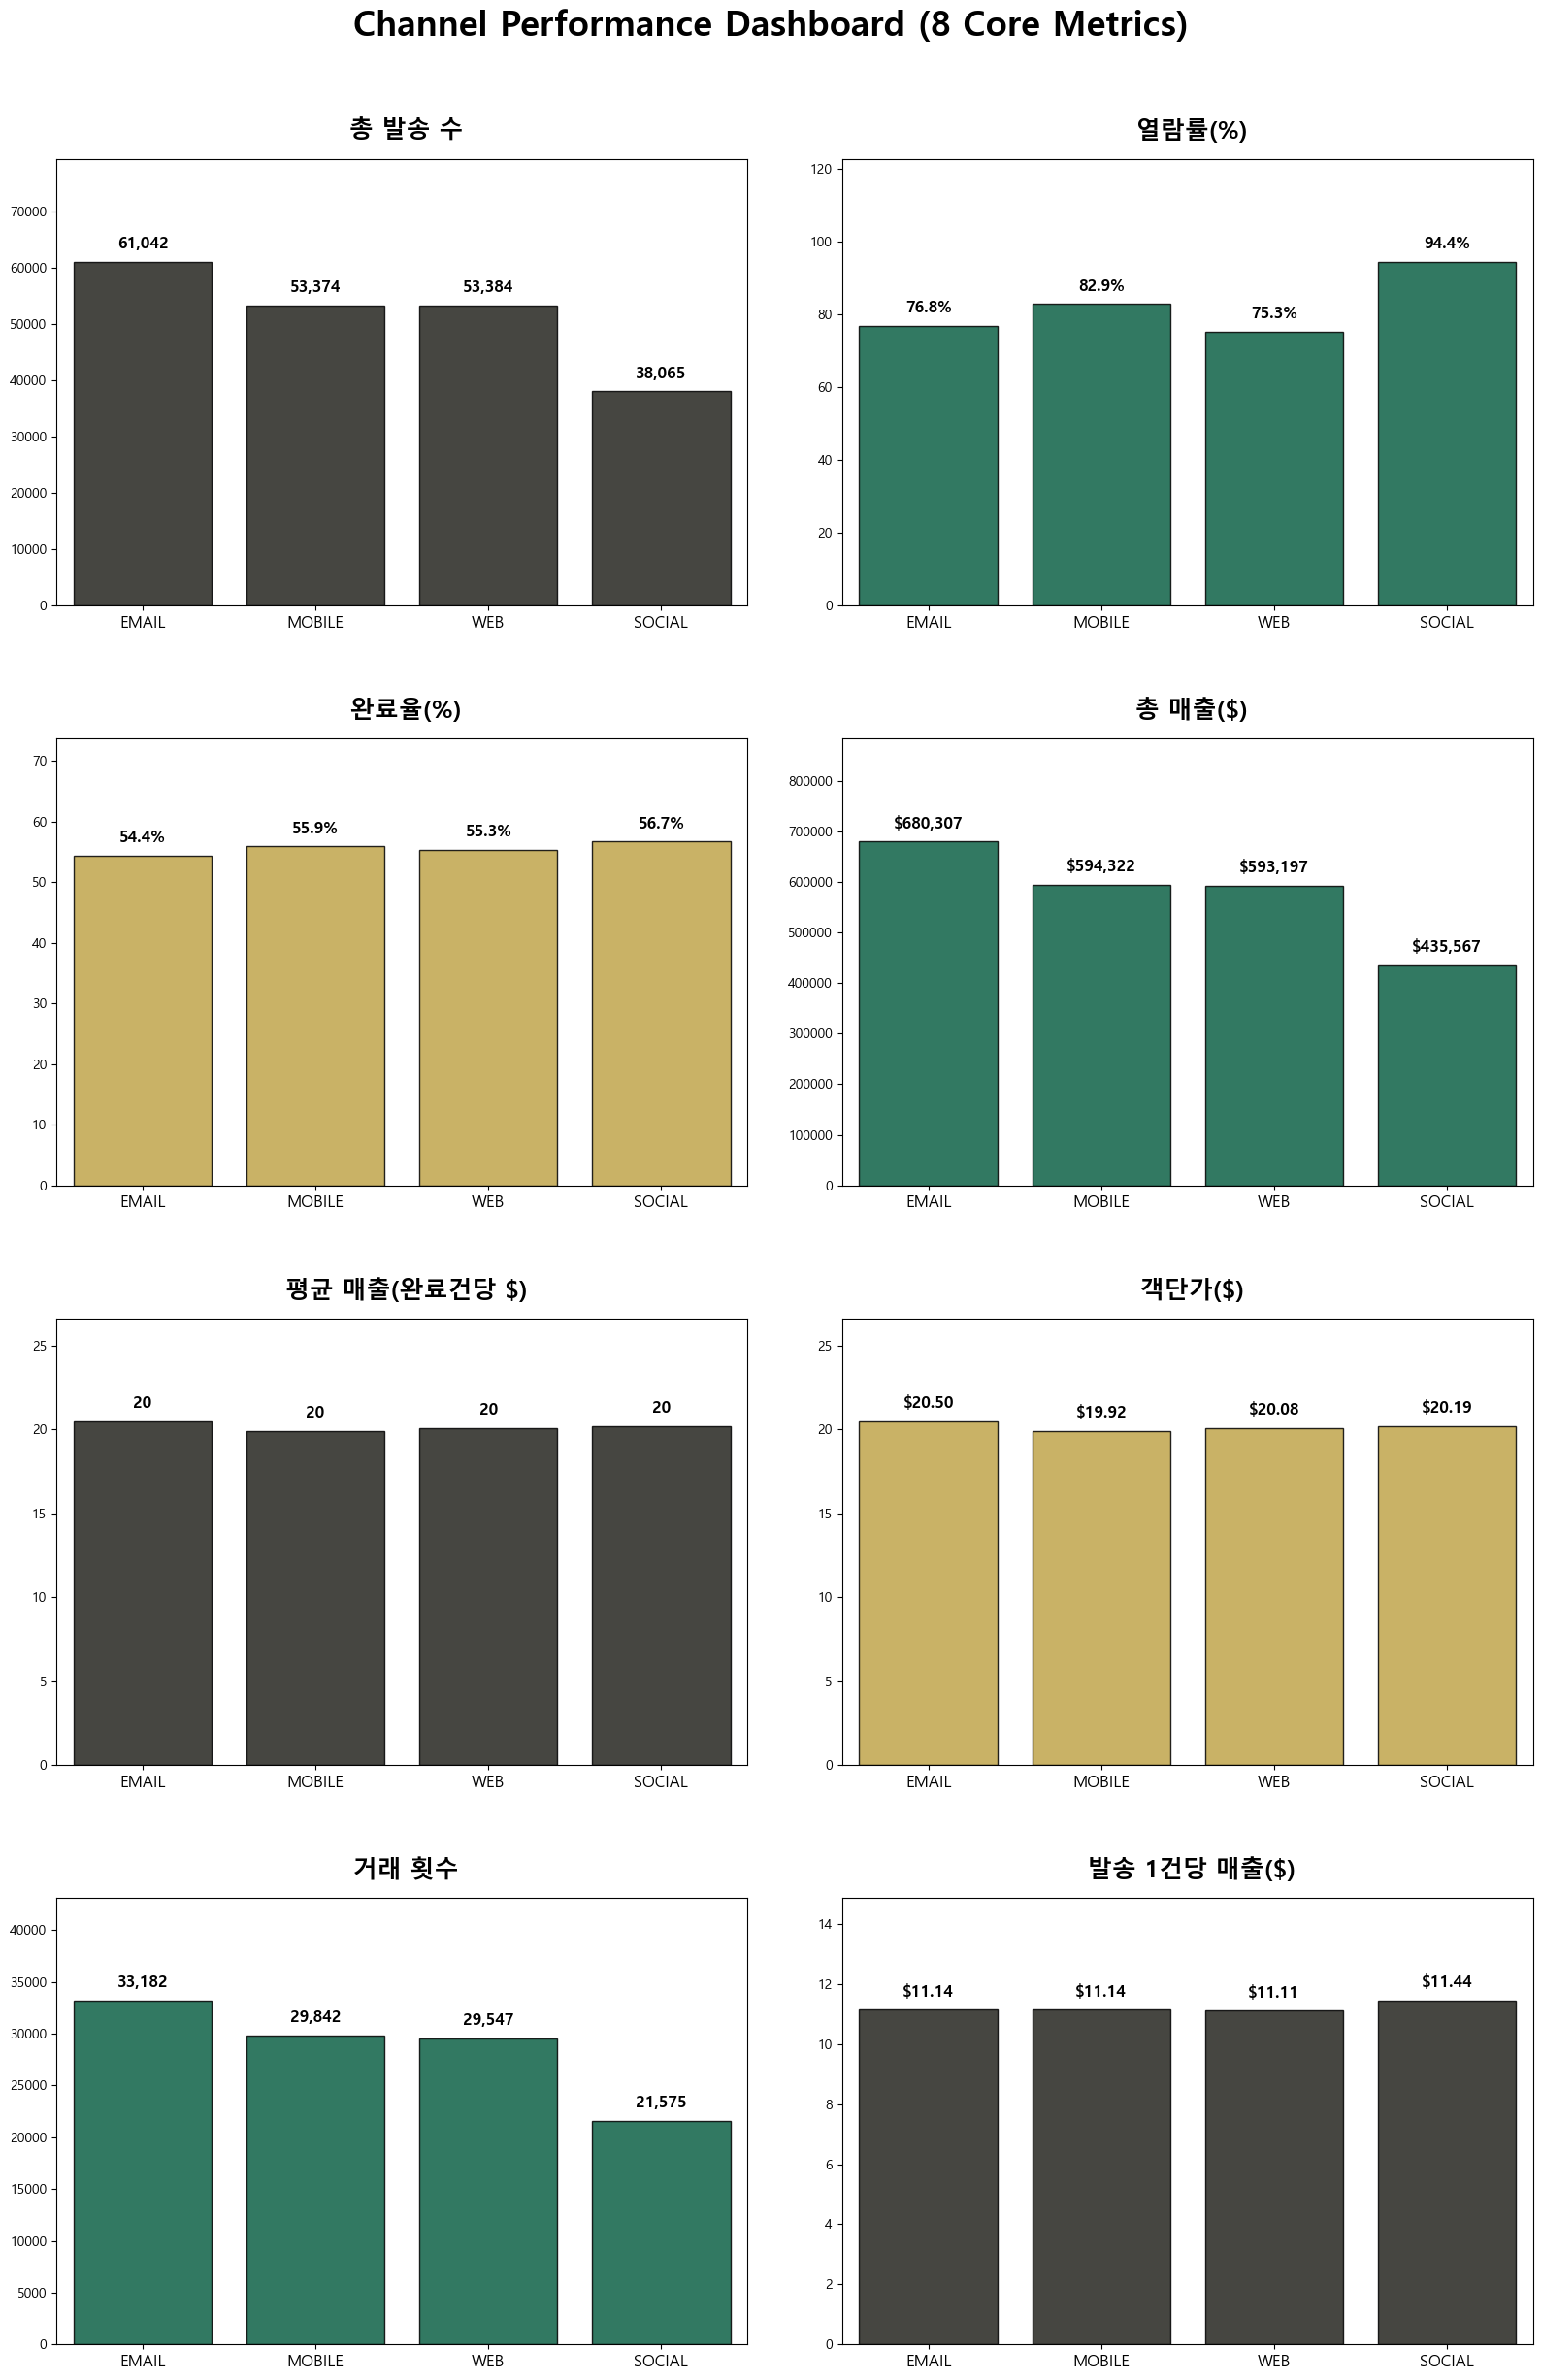

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 8개 지표 리스트
metrics = [
    '총 발송 수', '열람률(%)', '완료율(%)', '총 매출($)', 
    '평균 매출(완료건당 $)', '객단가($)', '거래 횟수', '발송 1건당 매출($)'
]

# 4행 2열 도화지 생성 (여유 있게 16x24 사이즈)
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.flatten()

# 스타벅스 테마 색상 (검정, 초록, 골드 조합)
colors = ['#27251F', '#00704A', '#D4AF37', '#00704A', '#27251F', '#D4AF37', '#00704A', '#27251F']

for i, metric in enumerate(metrics):
    sns.barplot(data=channel_kpi_df, x='채널(Channel)', y=metric, ax=axes[i], 
                color=colors[i], alpha=0.85, edgecolor='black')
    
    # 천장 높이기 (글자 들어갈 공간 확보)
    max_val = channel_kpi_df[metric].max()
    axes[i].set_ylim(0, max_val * 1.3) # 지표값보다 30% 더 높게 지붕 설정
    
    # 차트 꾸미기
    axes[i].set_title(f" {metric}", fontsize=18, fontweight='bold', pad=15)
    axes[i].set_xlabel('') 
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=12) # 채널 이름(WEB, EMAIL 등) 크게
    
    # 막대 위에 숫자 달아주기 (지표별 맞춤 포맷)
    for p in axes[i].patches:
        val = p.get_height()
        if '($)' in metric and '총' in metric:
            text = f'${val:,.0f}'
        elif '($)' in metric:
            text = f'${val:.2f}' 
        elif '%' in metric:
            text = f'{val:.1f}%' 
        else:
            text = f'{val:,.0f}' 
            
        axes[i].annotate(text, (p.get_x() + p.get_width() / 2., val),
                         ha='center', va='bottom', fontsize=12, fontweight='bold', 
                         xytext=(0, 7), textcoords='offset points')

# 전체 제목
plt.suptitle('Channel Performance Dashboard (8 Core Metrics)', fontsize=26, fontweight='bold', y=1.02)

# 간격 조절 (h_pad: 위아래 간격, w_pad: 좌우 간격)
plt.tight_layout(h_pad=5.0, w_pad=3.0)
plt.show()

In [26]:
# 🔍 특정 ID(person)의 모든 기록을 찾아라!
target_id = '4ac814a6d8dd461690c0bfeba4ab698e'

# 1. 해당 ID를 가진 행만 쏙 뽑아내기 (person 컬럼 기준)
user_history = df[df['person'] == target_id]

# 2. 결과 출력 (시간순으로 정렬해서 보면 이 고객의 동선이 다 보여요!)
print(f"✅ ID [{target_id}] 고객의 전체 활동 내역 (총 {len(user_history)}건)")
display(user_history.sort_values('time'))

# 3. 이 고객의 기본 프로필만 따로 보기 (성별, 나이, 소득 등)
print("\n👤 이 고객의 기본 프로필:")
user_profile = user_history[['gender', 'age', 'income', 'became_member_on']].drop_duplicates()
display(user_profile)

✅ ID [4ac814a6d8dd461690c0bfeba4ab698e] 고객의 전체 활동 내역 (총 19건)


,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label
11250,4ac814a6d8dd461690c0bfeba4ab698e,received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,1,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3
22067,4ac814a6d8dd461690c0bfeba4ab698e,viewed,18,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,1,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3
22068,4ac814a6d8dd461690c0bfeba4ab698e,transaction,18,NaN,14.10,NaN,1,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22069,4ac814a6d8dd461690c0bfeba4ab698e,completed,18,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,1,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3
27681,4ac814a6d8dd461690c0bfeba4ab698e,transaction,36,NaN,15.73,NaN,2,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30958,4ac814a6d8dd461690c0bfeba4ab698e,transaction,48,NaN,12.68,NaN,3,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41909,4ac814a6d8dd461690c0bfeba4ab698e,transaction,96,NaN,7.80,NaN,5,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45305,4ac814a6d8dd461690c0bfeba4ab698e,transaction,114,NaN,6.04,NaN,5,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52161,4ac814a6d8dd461690c0bfeba4ab698e,transaction,156,NaN,25.39,NaN,7,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71833,4ac814a6d8dd461690c0bfeba4ab698e,transaction,174,NaN,4.62,NaN,8,M,49.0,4ac814a6d8dd461690c0bfeba4ab698e,2017-10-20,46000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



👤 이 고객의 기본 프로필:


,gender,age,income,became_member_on
11250,M,49.0,46000.0,2017-10-20
